In [1]:
# Ячейка 1
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

# Проверяем наш Multi-GPU сетап
if torch.cuda.is_available():
    device = torch.device("cuda")
    gpu_count = torch.cuda.device_count()
    print(f"🔥 Двигатели запущены! Найдено GPU: {gpu_count}")
    for i in range(gpu_count):
        print(f"GPU {i}: {torch.cuda.get_device_name(i)}")
else:
    device = torch.device("cpu")
    print("⚠️ Внимание: GPU не найдено, работаем на CPU.")

🔥 Двигатели запущены! Найдено GPU: 2
GPU 0: Tesla T4
GPU 1: Tesla T4


In [3]:
# Ячейка 2
class LiquidLayer(nn.Module):
    def __init__(self, in_features, hidden_features, dt=0.05):
        super(LiquidLayer, self).__init__()
        self.in_features = in_features
        self.hidden_features = hidden_features
        self.dt = dt # Шаг времени для интеграции (чем меньше, тем "плавнее" жидкость)
        
        # Линейные трансформации для входа и рекуррентного состояния
        self.W_in = nn.Linear(in_features, hidden_features)
        self.W_h = nn.Linear(hidden_features, hidden_features)
        
        # Обучаемый параметр "вязкости" (State Persistence)
        # Инициализируем случайными положительными значениями
        self.tau = nn.Parameter(torch.rand(hidden_features) * 2.0 + 0.5)

    def forward(self, x):
        # Ожидаем размерность x: (batch_size, seq_len, in_features)
        batch_size, seq_len, _ = x.size()
        
        # Начальное состояние "жидкости" (пустой резервуар)
        h = torch.zeros(batch_size, self.hidden_features, device=x.device)
        outputs = []

        # Пропускаем тензоры через время
        for t in range(seq_len):
            xt = x[:, t, :]
            
            # 1. Вычисляем входящий "поток" (Forcing term)
            forcing_term = torch.tanh(self.W_in(xt) + self.W_h(h))
            
            # 2. LNN дифференциальное уравнение: dh/dt = -h/tau + forcing_term
            # Ограничиваем tau снизу, чтобы избежать деления на ноль
            safe_tau = torch.clamp(self.tau, min=0.01) 
            dh = (-h / safe_tau) + forcing_term
            
            # 3. Шаг интеграции Эйлера (обновление состояния жидкости)
            h = h + self.dt * dh
            
            outputs.append(h.unsqueeze(1))

        # Собираем историю состояний обратно в тензор
        return torch.cat(outputs, dim=1)

# Обертка для предсказания (Жидкий слой + Линейный выход)
class LiquidNet(nn.Module):
    def __init__(self, in_features, hidden_features, out_features):
        super(LiquidNet, self).__init__()
        self.liquid = LiquidLayer(in_features, hidden_features)
        self.readout = nn.Linear(hidden_features, out_features)
        
    def forward(self, x):
        liquid_states = self.liquid(x)
        # Берем только последнее состояние для предсказания следующего шага
        final_state = liquid_states[:, -1, :] 
        return self.readout(final_state)

In [8]:
# Ячейка 3: Финансовый датасет со скрытым сигналом
import torch.nn.functional as F

def generate_market_data_with_signal(seq_len=60, samples=5000, future_steps=5):
    X_data, Y_data = [], []
    for _ in range(samples):
        # 1. Скрытый макро-тренд (медленная экономическая волна)
        phase = np.random.uniform(0, 2 * np.pi)
        t = np.linspace(0, 4 * np.pi, seq_len + future_steps)
        macro_trend = np.sin(t + phase) * 0.03  # Слабый, но предсказуемый сигнал
        
        # 2. Рыночный хаос (Случайный шум + Прыжки волатильности)
        noise = np.random.normal(0, 0.02, seq_len + future_steps)
        jumps = np.random.choice([0, 1, -1], size=seq_len + future_steps, p=[0.96, 0.02, 0.02]) * np.random.uniform(0.1, 0.25)
        
        # 3. Собираем цену: Тренд + Шум + Прыжки
        returns = macro_trend + noise + jumps
        price_path = np.cumsum(returns)
        
        # Нормализуем окно
        x_window = price_path[:seq_len]
        x_window = x_window - x_window[0] 
        
        # Target: вырастет ли цена через future_steps?
        current_price = price_path[seq_len-1]
        future_price = price_path[-1]
        y_label = 1.0 if future_price > current_price else 0.0
        
        X_data.append(x_window)
        Y_data.append(y_label)
        
    return np.array(X_data), np.array(Y_data)

print("📊 Генерируем рыночные данные со скрытым сигналом...")
# Увеличим датасет, чтобы сети было проще найти паттерн
X_raw, Y_raw = generate_market_data_with_signal(seq_len=60, samples=10000)

X = torch.tensor(X_raw, dtype=torch.float32).unsqueeze(-1)
Y = torch.tensor(Y_raw, dtype=torch.float32).unsqueeze(-1)

dataset = torch.utils.data.TensorDataset(X, Y)
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, test_size])

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=256, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=256, shuffle=False)

# Инициализация (Чуть увеличим скрытый слой для сложности)
model = LiquidNet(in_features=1, hidden_features=64, out_features=1)
if torch.cuda.device_count() > 1:
    model = nn.DataParallel(model)
model.to(device)

criterion = nn.BCEWithLogitsLoss()
# Понизим Learning Rate для более плавной сходимости
optimizer = optim.Adam(model.parameters(), lr=0.002)

epochs = 50
model.train()
for epoch in range(epochs):
    epoch_loss, correct, total = 0.0, 0, 0
    for batch_x, batch_y in train_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        
        optimizer.zero_grad()
        logits = model(batch_x)
        loss = criterion(logits, batch_y)
        loss.backward()
        
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        epoch_loss += loss.item()
        preds = (logits > 0).float()
        correct += (preds == batch_y).sum().item()
        total += batch_y.size(0)
        
    if (epoch+1) % 5 == 0:
        acc = correct / total * 100
        print(f"Epoch {epoch+1:02d}/{epochs} | Loss: {epoch_loss/len(train_loader):.4f} | Train Acc: {acc:.2f}%")

📊 Генерируем рыночные данные со скрытым сигналом...
Epoch 05/50 | Loss: 0.6642 | Train Acc: 61.31%
Epoch 10/50 | Loss: 0.5287 | Train Acc: 77.50%
Epoch 15/50 | Loss: 0.4079 | Train Acc: 83.15%
Epoch 20/50 | Loss: 0.4044 | Train Acc: 83.20%
Epoch 25/50 | Loss: 0.4039 | Train Acc: 83.36%
Epoch 30/50 | Loss: 0.4091 | Train Acc: 83.05%
Epoch 35/50 | Loss: 0.4021 | Train Acc: 83.46%
Epoch 40/50 | Loss: 0.4014 | Train Acc: 83.11%
Epoch 45/50 | Loss: 0.4055 | Train Acc: 83.14%
Epoch 50/50 | Loss: 0.3982 | Train Acc: 83.31%


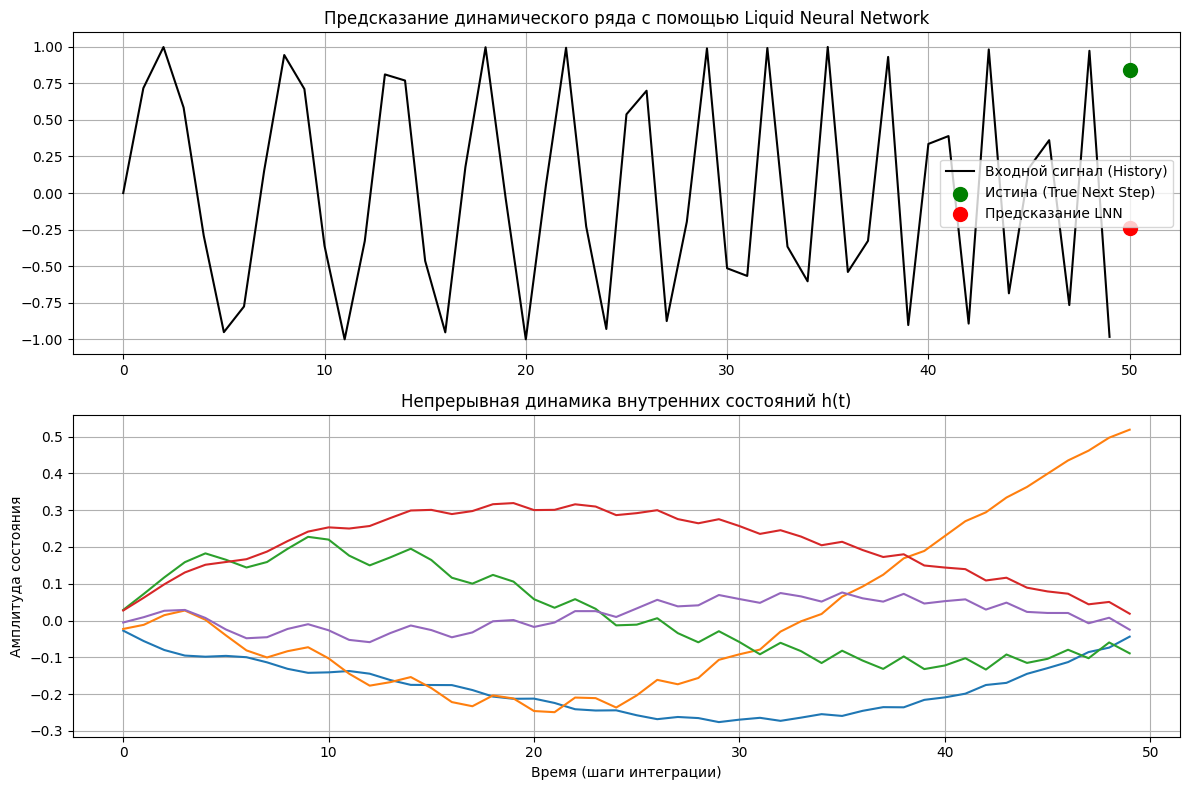

Средняя вязкость (tau) в сети: 1.423
Минимальная вязкость: 0.548 (быстрые нейроны)
Максимальная вязкость: 2.549 (медленные нейроны-контекста)


In [9]:
# Ячейка 4 (Исправленная)
model.eval()

# Генерируем тестовый семпл
test_raw = generate_dynamic_series(seq_len=50, samples=1)
test_x = torch.tensor(test_raw[:, :-1], dtype=torch.float32).unsqueeze(-1).to(device)
true_y = test_raw[0, -1]

# Отключаем градиенты для ВСЕГО инференса
with torch.no_grad():
    pred_y = model(test_x).cpu().numpy()[0][0]
    
    # Достанем внутренние состояния из первого слоя 
    core_model = model.module if isinstance(model, nn.DataParallel) else model
    # Теперь PyTorch не ругнется, так как мы внутри no_grad()
    liquid_states = core_model.liquid(test_x).cpu().numpy()[0] # (seq_len, hidden_features)

# Рисуем графики
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# График 1: Входной сигнал и предсказание
t_x = np.arange(50)
ax1.plot(t_x, test_raw[0, :-1], label="Входной сигнал (History)", color="black")
ax1.scatter([50], [true_y], color="green", s=100, label="Истина (True Next Step)", zorder=5)
ax1.scatter([50], [pred_y], color="red", s=100, label="Предсказание LNN", zorder=5)
ax1.set_title("Предсказание динамического ряда с помощью Liquid Neural Network")
ax1.legend()
ax1.grid(True)

# График 2: Визуализация "жидких" состояний (активации 5 случайных нейронов)
ax2.plot(liquid_states[:, :5])
ax2.set_title("Непрерывная динамика внутренних состояний h(t)")
ax2.set_xlabel("Время (шаги интеграции)")
ax2.set_ylabel("Амплитуда состояния")
ax2.grid(True)

plt.tight_layout()
plt.show()

# Печатаем распределение обученных tau (вязкости)
trained_tau = core_model.liquid.tau.detach().cpu().numpy()
print(f"Средняя вязкость (tau) в сети: {np.mean(trained_tau):.3f}")
print(f"Минимальная вязкость: {np.min(trained_tau):.3f} (быстрые нейроны)")
print(f"Максимальная вязкость: {np.max(trained_tau):.3f} (медленные нейроны-контекста)")